# Classification EDA (Exploratory Data Analysis)
This notebook performs the required visualizations outlined in Review 1, Section A of the rubric.

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Recommended colorblind-friendly palette from the guidelines
sns.set_palette('colorblind')
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Dataset Loading

In [4]:
# Note: We do EDA on the RAW data before heavy preprocessing/encoding, 
# but you can also use the lightly cleaned data (without constant columns/duplicates).
DATA_PATH = "../data/RT_IOT2022_cleaned.csv" 
df = pd.read_csv(DATA_PATH)
print("Data loaded. Shape:", df.shape)

Data loaded. Shape: (117922, 83)


## 2. Target Distribution (Attack_type)
**Requirement:** target distribution reported clearly.

**Observation:** The dataset is heavily imbalanced. The DOS_SYN_Hping attack dominates the dataset (accounting for ~76% of the traffic), while several classes like NMAP_FIN_SCAN have extremely few samples. This severe imbalance strongly justifies our decision to use **Stratified Splitting** for our train/test sets to ensure minority classes are represented, and it highlights why accuracy alone won't be a sufficient metric for our models (we must rely on weighted F1-score and ROC-AUC as required by the rubric).

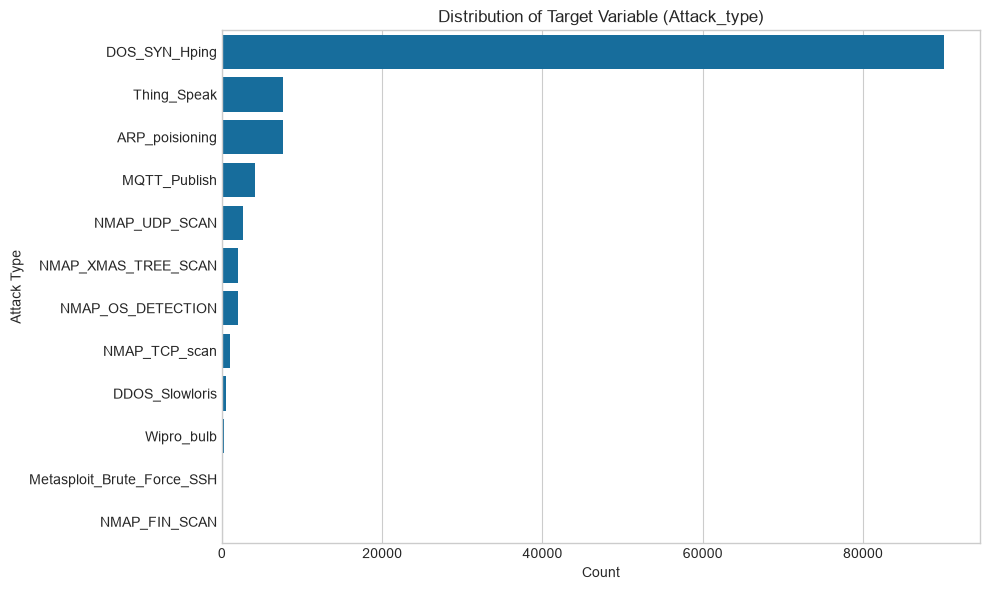

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Attack_type', data=df, order=df['Attack_type'].value_counts().index)
plt.title("Distribution of Target Variable (Attack_type)")
plt.xlabel("Count")
plt.ylabel("Attack Type")
plt.tight_layout() # Guideline 7.3: prevent clipped labels
plt.show()

## 3. Distribution Plots for Features
**Requirement:** distribution plots for each feature.
*Note: Since this dataset has ~80 features, plotting all of them at once can crash the notebook. We will plot a subset of the most important continuous features here.* 

**Observation:** The visualizations reveal that most network traffic features (like flow_duration, fwd_pkts_tot, and header sizes) are **extremely right-skewed** (some with skewness > 100). This indicates the presence of severe outliers, which is typical for network traffic (e.g., a few massive data transfers or prolonged connections). This observation directly supports our preprocessing strategy of using percentile capping (1st and 99th percentiles) rather than standard deviation methods to treat outliers without dropping minority attacks.

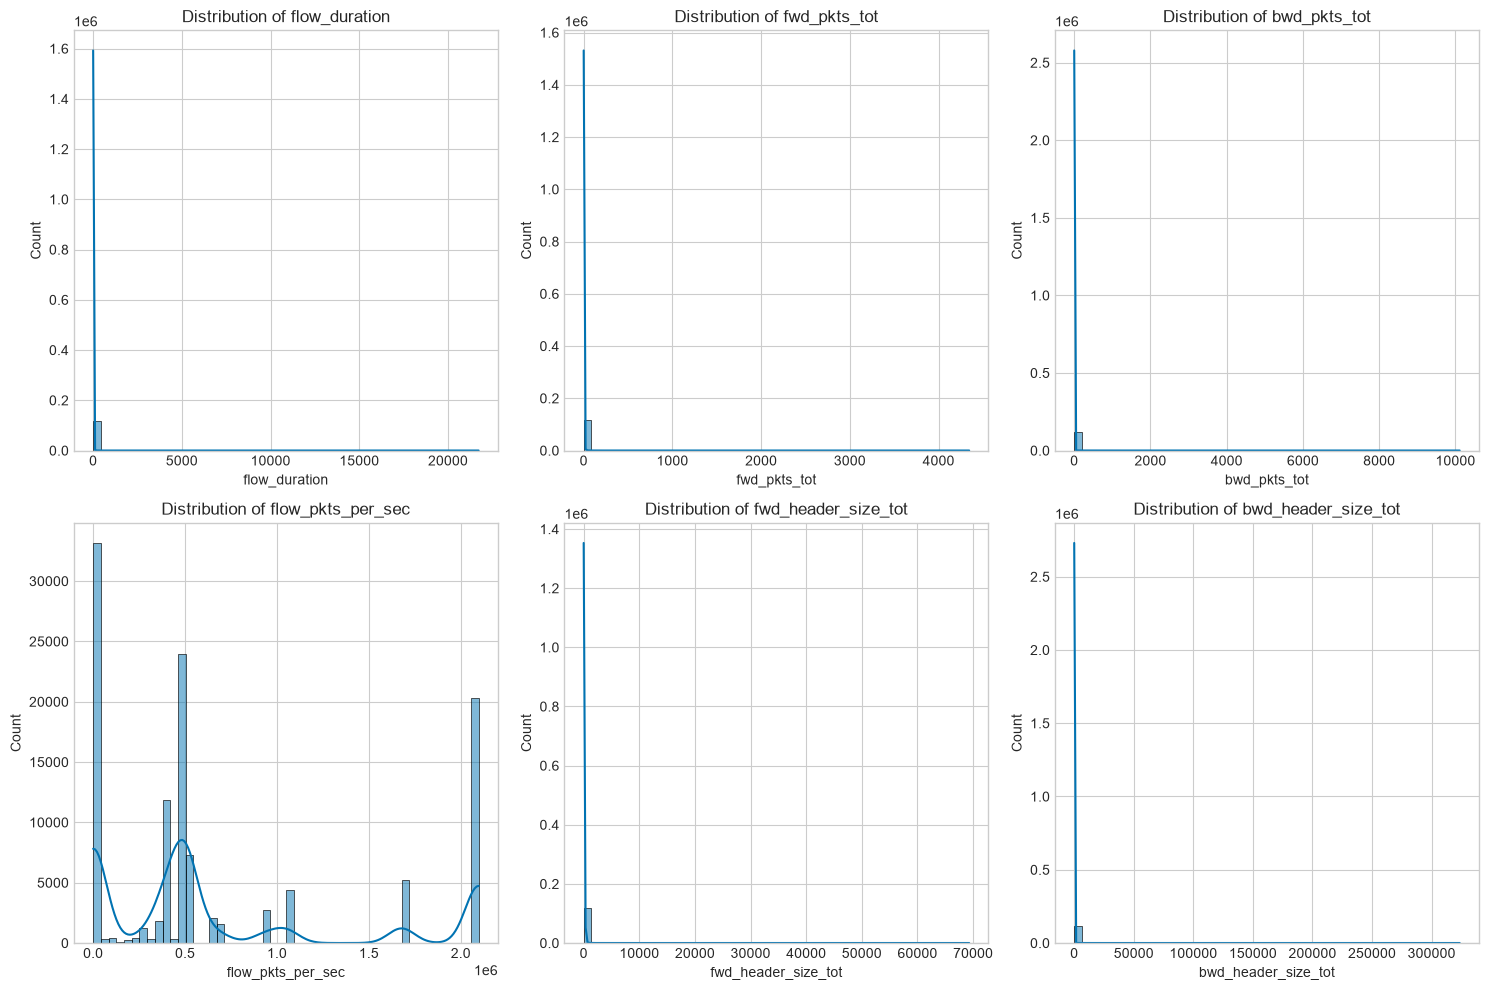

In [6]:
# Select a subset of key numeric features to prevent notebook from freezing
key_features = ['flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'flow_pkts_per_sec', 'fwd_header_size_tot', 'bwd_header_size_tot']

plt.figure(figsize=(15, 10))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## 4. Correlation Heatmap
**Requirement:** correlation heatmap.

**Observation:** The heatmap shows several clusters of highly correlated features. For example, forward packet counts (fwd_pkts_tot) are strongly correlated with forward data packets and header sizes (>0.8). Furthermore, packet transmission rates (fwd_pkts_per_sec, bwd_pkts_per_sec, and flow_pkts_per_sec) have near-perfect linear correlations (1.0). This indicates high multicollinearity in the dataset, meaning many features are redundant. Tree-based models (Random Forest, XGBoost) will handle this well, but for models like Logistic Regression and SVM, dimensionality reduction or feature selection might improve training efficiency.

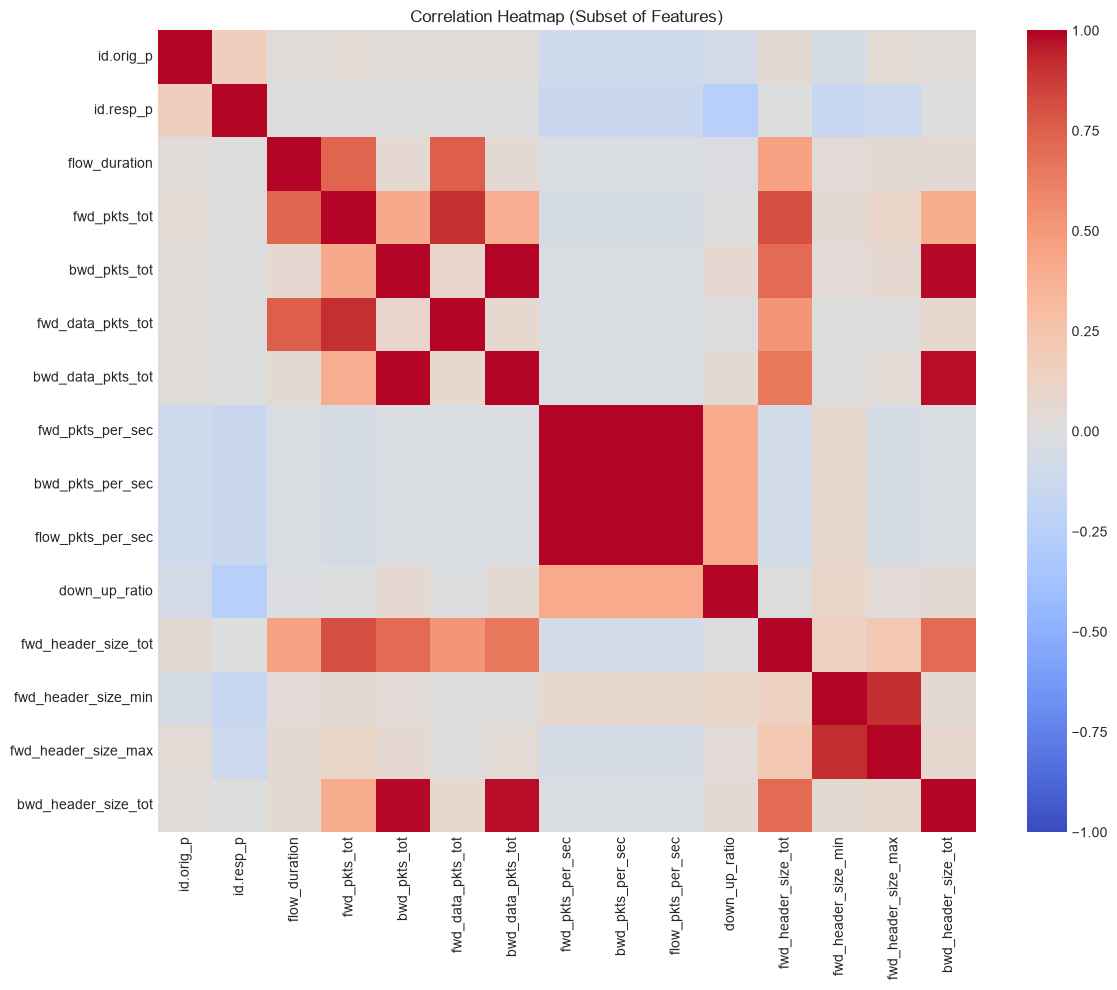

In [7]:
# Compute correlation matrix for a subset of features to keep it readable
numeric_cols = df.select_dtypes(include=[np.number]).columns
subset_cols = numeric_cols[:15] # Taking first 15 for readability
corr_matrix = df[subset_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Subset of Features)")
plt.tight_layout()
plt.show()

## 5. Feature-Target Relationships (Scatter Plots)
**Requirement:** at least two scatter plots showing feature-target relationships.
*Since our target is categorical, a great way to show this relationship is by using a scatter plot of two features and coloring the dots by the target class (Attack_type).*

**Observation:** The scatter plots clearly show that different attack types exhibit distinct spatial patterns. In the Flow Duration vs Forward Packets plot, we can see that certain attacks are clustered tightly near zero duration (like rapid automated scans or SYN floods), while others spread out with higher durations. Similarly, the packet rate plot demonstrates clear boundaries between different classes based on their network footprint. These distinct boundaries confirm that our models should be able to separate the classes effectively using these features.

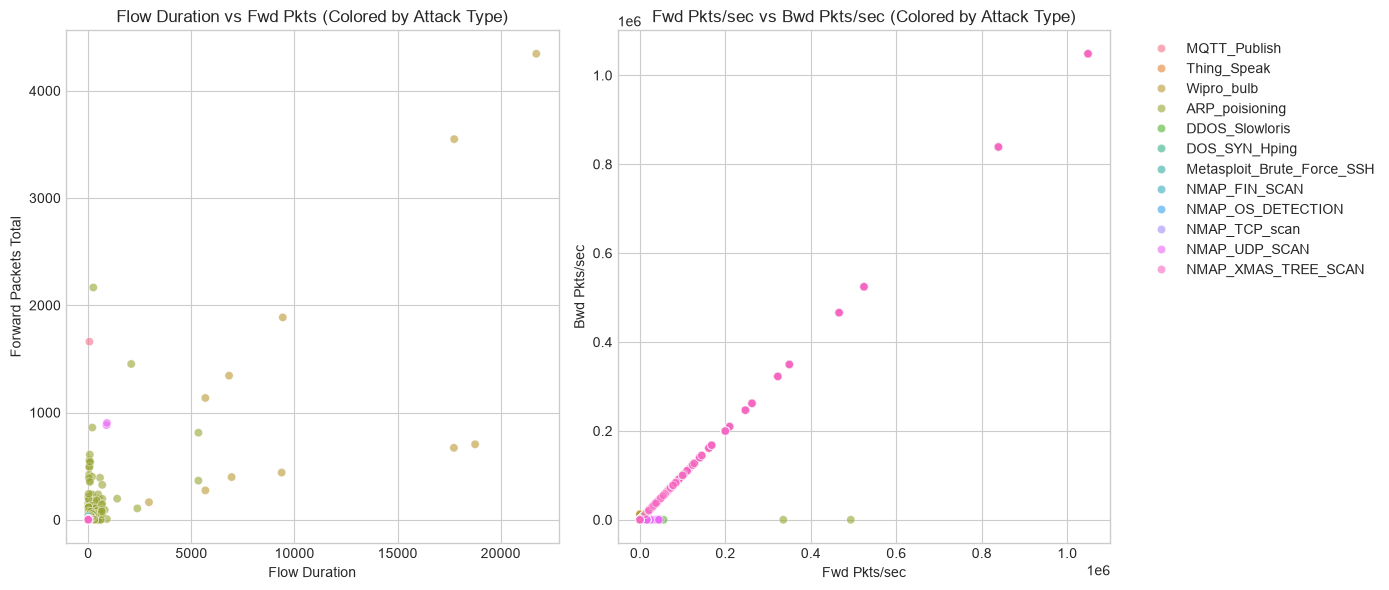

In [8]:
plt.figure(figsize=(14, 6))

# Scatter Plot 1
plt.subplot(1, 2, 1)
sns.scatterplot(x='flow_duration', y='fwd_pkts_tot', hue='Attack_type', data=df, alpha=0.6, legend=False)
plt.title("Flow Duration vs Fwd Pkts (Colored by Attack Type)")
plt.xlabel("Flow Duration")
plt.ylabel("Forward Packets Total")

# Scatter Plot 2
plt.subplot(1, 2, 2)
sns.scatterplot(x='fwd_pkts_per_sec', y='bwd_pkts_per_sec', hue='Attack_type', data=df, alpha=0.6, legend='brief')
plt.title("Fwd Pkts/sec vs Bwd Pkts/sec (Colored by Attack Type)")
plt.xlabel("Fwd Pkts/sec")
plt.ylabel("Bwd Pkts/sec")

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()